# Limb Sounding Validation: TIMED SABER

This notebook validates the limb sounding analysis in TAT-C (`collect_limb_observations`, see the [Limb Sounding Observations](../examples/CollectLimb.ipynb) example) against the [Sounding of the Atmosphere using Broadband Emission Radiometry (SABER)](https://saber.gats-inc.com/) instrument aboard NASA's Thermosphere Ionosphere Mesosphere Energetics and Dynamics (TIMED) spacecraft.

SABER complements the [Aura MLS validation](ValidateLimbMLS.ipynb) in two ways. It looks sideways, perpendicular to the flight direction (`scan_azimuth = 90`), rather than forward. And it alternates upward and downward vertical scans, exercising both `ScanDirection` options.

The comparison uses one full day of SABER data (21 September 2026) and follows the same four tests as the MLS notebook:

1. **Orbit.** Does TAT-C's SGP4 propagation of a public two-line element (TLE) set reproduce TIMED's position?
2. **Tangent point geometry.** Given the same time and target altitude as each SABER sample, does TAT-C place the tangent point at the same location?
3. **Vertical scans.** Starting TAT-C scans at the actual SABER scan start times, how closely do the simulated samples match the measured ones?
4. **Daily sampling.** Does a planning-style TAT-C run reproduce the number, latitude distribution, and local solar time of SABER's profiles?

## Reference Data

SABER Level 2A files (version 2.08) are distributed by GATS, Inc. without registration, one netCDF file per orbit. Each file holds the *events* (vertical scans) of one orbit, with a scan direction flag (`mode`: 0 for down, 1 for up) and, at each level of a 0.34 km altitude grid, the sample time and the geodetic latitude, longitude, and altitude of both the spacecraft and the tangent point.

Two details of the format matter here. First, `time` counts milliseconds from midnight of the orbit's *start* date, so it exceeds 24 hours for events after midnight in an orbit that spans two days. Second, levels are stored top-down, so samples of upward scans appear in reverse chronological order.

The 16 orbits overlapping 21 September 2026 (about 90 MB) are downloaded to a local `data` directory, if not already present. Reading the files requires the `netCDF4` package (`pip install netCDF4`).

In [1]:
from pathlib import Path

import requests

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
SABER_URL = "https://data.gats-inc.com/saber/Version2_0/Level2A/2026"
saber_files = [
    DATA_DIR / f"SABER_L2A_{2026263 if orbit_number == 134529 else 2026264}_{orbit_number}_02.08.nc"
    for orbit_number in range(134529, 134545)
]
for file in saber_files:
    if not file.exists():
        day = file.name.split("_")[2][4:]
        response = requests.get(f"{SABER_URL}/{day}/{file.name}", timeout=120)
        response.raise_for_status()
        file.write_bytes(response.content)

## Setup

TIMED flies a 625 km, 74.1 deg inclination orbit. It is modeled with the most recent TLE available at the time of this analysis (epoch 1 October 2026), so the analysis day is about 10 days before the TLE epoch; Test 1 quantifies the resulting propagation error. Helper functions are the same as in the MLS notebook.

In [2]:
from datetime import datetime, timedelta, timezone

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pandas as pd
from pyproj import Geod, Transformer
from skyfield.api import Distance, wgs84
from skyfield.positionlib import Geocentric

from tatc.analysis import ScanDirection, collect_limb_observations
from tatc.utils import rectangular_to_geodetic
from tatc.analysis.limb_sampling import (
    _limb_tangent_point,
    _sample_limb_scan,
)
from tatc.constants import timescale
from tatc.schemas import GeneralPerturbationsOrbit, Satellite

timed = Satellite(
    name="TIMED",
    orbit=GeneralPerturbationsOrbit.from_tle(
        [
            "1 26998U 01055B   26274.38013578  .00000670  00000+0  64140-4 0  9992",
            "2 26998  74.0695  21.1640 0001373 226.8810 133.2260 14.95484167346696",
        ]
    ),
)
orbit = timed.orbit.to_gp_orbit()

GEOD = Geod(ellps="WGS84")
DAY0 = datetime(2026, 9, 21, tzinfo=timezone.utc)


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series(
        {
            "n": x.size,
            "mean": x.mean(),
            "std": x.std(),
            "median": np.median(x),
            "p95 |x|": np.percentile(np.abs(x), 95),
            "max |x|": np.abs(x).max(),
        }
    )


def along_right(lon_ref, lat_ref, lon, lat, heading):
    """Offset (km) from reference points, along and to the right of a heading (deg)."""
    azimuth, _, distance = GEOD.inv(lon_ref, lat_ref, lon, lat)
    relative = np.radians(np.asarray(azimuth) - heading)
    return distance * np.cos(relative) / 1e3, distance * np.sin(relative) / 1e3


def binned_median(x, y, edges):
    """Median of y within bins of x."""
    centers = (edges[1:] + edges[:-1]) / 2
    medians = [
        np.median(y[(x >= lo) & (x < hi)]) if np.any((x >= lo) & (x < hi)) else np.nan
        for lo, hi in zip(edges[:-1], edges[1:])
    ]
    return centers, np.array(medians)


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)

## The SABER Vertical Scan

Each event is loaded with its samples in chronological order, keeping only valid levels. Events are assigned to the day by their first sample time.

In [3]:
FIELDS = ["time", "tpaltitude", "tplatitude", "tplongitude", "sclatitude", "sclongitude", "scaltitude"]
events = []
for file in saber_files:
    ds = nc.Dataset(file)
    ds.set_auto_mask(False)
    orbit_start_date = datetime.strptime(ds.Data_Start_Time[:7], "%Y%j").replace(tzinfo=timezone.utc)
    data = {name: ds[name][:] for name in FIELDS}
    for e, mode in enumerate(ds["mode"][:]):
        ok = (
            (data["tpaltitude"][e] > 0)
            & (data["time"][e] >= 0)
            & (np.abs(data["tplatitude"][e]) <= 90)
            & (np.abs(data["sclatitude"][e]) <= 90)
        )
        if ok.sum() < 50:
            continue
        order = np.argsort(data["time"][e][ok])
        event = {name: data[name][e][ok][order].astype(float) for name in FIELDS}
        event["datetime"] = [orbit_start_date + timedelta(milliseconds=ms) for ms in event["time"]]
        event["elapsed"] = (event["time"] - event["time"][0]) / 1e3
        event["upward"] = bool(mode == 1)
        event["northbound"] = event["sclatitude"][-1] > event["sclatitude"][0]
        if DAY0 <= event["datetime"][0] < DAY0 + timedelta(days=1):
            events.append(event)


def heading(event, i):
    """Spacecraft ground track heading (deg) at sample i of an event."""
    j = min(i + 1, len(event["time"]) - 1)
    return GEOD.inv(
        event["sclongitude"][j - 1], event["sclatitude"][j - 1], event["sclongitude"][j], event["sclatitude"][j]
    )[0]


upward = np.array([e["upward"] for e in events])
starts = np.array([(e["datetime"][0] - DAY0).total_seconds() for e in events])
durations = np.array([e["elapsed"][-1] for e in events])
bottoms = np.array([e["tpaltitude"].min() for e in events])
tops = np.array([e["tpaltitude"].max() for e in events])
mid = [len(e["time"]) // 2 for e in events]
view_azimuth = np.array(
    [
        GEOD.inv(e["sclongitude"][m], e["sclatitude"][m], e["tplongitude"][m], e["tplatitude"][m])[0] - heading(e, m)
        for e, m in zip(events, mid)
    ]
)
view_azimuth = (view_azimuth + 180) % 360 - 180

pd.Series(
    {
        "upward scans": upward.sum(),
        "downward scans": (~upward).sum(),
        "scan duration (s)": np.median(durations),
        "scan bottom (km)": np.median(bottoms),
        "scan top (km)": np.median(tops),
        "start spacing after an upward scan (s)": np.median(np.diff(starts)[upward[:-1]]),
        "start spacing after a downward scan (s)": np.median(np.diff(starts)[~upward[:-1]]),
        "tangent point azimuth from heading (deg)": np.median(view_azimuth),
        "range of that azimuth (deg)": np.ptp(view_azimuth),
    }
).to_frame("SABER")

,SABER
upward scans,631.000000
downward scans,631.000000
scan duration (s),17.783000
scan bottom (km),12.746028
scan top (km),155.648361
start spacing after an upward scan (s),81.815000
start spacing after a downward scan (s),48.098000
tangent point azimuth from heading (deg),-90.459580
range of that azimuth (deg),8.347254


SABER viewed about 90 deg to the left of the ground track all day (the side TIMED points SABER toward is periodically switched by a yaw maneuver, which did not occur on this day). TAT-C measures `scan_azimuth` from the velocity toward the orbit normal $\hat{n} = x_{sat} \times v_{sat}$, which points to the left of the flight direction, so SABER corresponds to `scan_azimuth = 90`.

## Test 1: Orbit

TAT-C's propagated position is compared with the spacecraft geodetic position at the middle sample of each event.

In [4]:
t1 = [e["datetime"][m] for e, m in zip(events, mid)]
g1 = wgs84.geographic_position_of(orbit.get_orbit_track(t1))
along1, right1 = along_right(
    [e["sclongitude"][m] for e, m in zip(events, mid)],
    [e["sclatitude"][m] for e, m in zip(events, mid)],
    g1.longitude.degrees,
    g1.latitude.degrees,
    np.array([heading(e, m) for e, m in zip(events, mid)]),
)
test1 = pd.DataFrame(
    {
        "along-track (km)": summarize(along1),
        "cross-track (km)": summarize(right1),
        "altitude (km)": summarize(g1.elevation.km - [e["scaltitude"][m] for e, m in zip(events, mid)]),
    }
).T
test1.round(3)

,n,mean,std,median,p95 |x|,max |x|
along-track (km),1262.0,-5.099,0.784,-5.187,6.346,6.649
cross-track (km),1262.0,-0.006,1.012,-0.010,1.508,1.642
altitude (km),1262.0,-0.006,0.318,-0.005,0.575,0.700


The TLE places TIMED about 5 km (less than 1 s) behind its reported position, a typical propagation error for a TLE 10 days from its epoch.

## Test 2: Tangent Point Geometry

For every eighth level of every event, TAT-C's tangent point routine (`_limb_tangent_point`, which `collect_limb_observations` uses for each sample) is evaluated at the exact SABER sample time, with `scan_azimuth = 90` and the SABER tangent altitude as the requested elevation.

In [5]:
samples = [(e, i) for e in events for i in range(0, len(e["time"]), 8)]
t2 = [e["datetime"][i] for e, i in samples]
target = np.array([e["tpaltitude"][i] * 1e3 for e, i in samples])
ref_lat = np.array([e["tplatitude"][i] for e, i in samples])
ref_lon = np.array([e["tplongitude"][i] for e, i in samples])
northbound = np.array([e["northbound"] for e, _ in samples])
ts2 = timescale.from_datetimes(t2)
tp_p, in_domain = _limb_tangent_point(orbit.get_orbit_track(t2), 90.0, target)
g2 = wgs84.geographic_position_of(Geocentric(Distance(m=tp_p).au, None, ts2))
along2, right2 = along_right(
    ref_lon, ref_lat, g2.longitude.degrees, g2.latitude.degrees, np.array([heading(e, i) for e, i in samples])
)
d_north = (g2.latitude.degrees - ref_lat) * 111.2
d_east = ((g2.longitude.degrees - ref_lon + 180) % 360 - 180) * 111.2 * np.cos(np.radians(ref_lat))
test2 = pd.DataFrame(
    {
        "altitude error (km)": summarize((g2.elevation.m - target) / 1e3),
        "along-track (km)": summarize(along2),
        "cross-track (km)": summarize(right2),
        "horizontal (km)": summarize(np.hypot(along2, right2)),
        "eastward (km)": summarize(d_east),
        "northward (km)": summarize(d_north),
    }
).T
test2.round(3)

,n,mean,std,median,p95 |x|,max |x|
altitude error (km),62152.0,0.000,0.000,0.000,0.000,0.000
along-track (km),62152.0,15.410,18.470,16.238,41.153,43.668
cross-track (km),62152.0,5.664,25.799,-0.544,40.054,42.098
horizontal (km),62152.0,34.154,10.478,35.424,50.186,52.468
eastward (km),62152.0,26.990,14.864,30.898,43.827,46.514
northward (km),62152.0,3.021,17.788,5.030,29.763,32.591


Requested altitudes are reproduced exactly, but horizontal positions differ by about 35 km. That is much more than for MLS (1.8 km), and the difference is nearly the same at all altitudes. Separating ascending (northbound) and descending passes shows that TAT-C's tangent points lie consistently east of SABER's at low and middle latitudes, whichever side of the track SABER is looking toward.

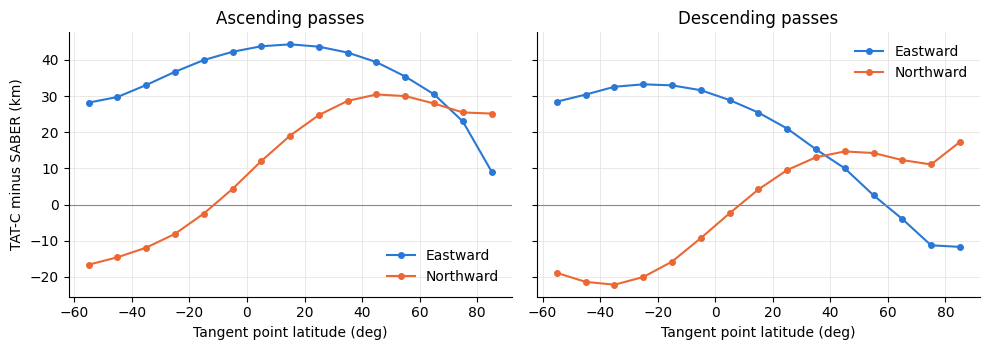

In [6]:
edges = np.arange(-60, 91, 10)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, mask, title in [(axes[0], northbound, "Ascending passes"), (axes[1], ~northbound, "Descending passes")]:
    ax.plot(*binned_median(ref_lat[mask], d_east[mask], edges), color=BLUE, marker="o", ms=4, label="Eastward")
    ax.plot(*binned_median(ref_lat[mask], d_north[mask], edges), color=ORANGE, marker="o", ms=4, label="Northward")
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.set(xlabel="Tangent point latitude (deg)", title=title)
    ax.legend(frameon=False)
axes[0].set_ylabel("TAT-C minus SABER (km)")
fig.tight_layout()
plt.show()

To see whether this residual comes from TAT-C or from the reference data, the internal consistency of the SABER geolocation is checked as in the MLS notebook. Each reported tangent point should be the point of minimum geodetic altitude on the straight line from the reported spacecraft position through it. For MLS this *tangency defect* is exactly zero. For SABER it is not: the true tangent point of SABER's own line of sight lies tens of kilometers from the reported one, the same order as the TAT-C residual. (Refraction cannot explain this, since the defect does not vary with altitude.) The next section identifies its main cause.

In [7]:
TO_ECEF = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)


def tangency_defect(sc_lon, sc_lat, sc_alt, tp_lon, tp_lat, tp_alt):
    """Distance (km) from each reported tangent point to the true tangent point
    (minimum geodetic altitude) of the straight line from the spacecraft through it."""
    s = np.array(TO_ECEF.transform(sc_lon, sc_lat, sc_alt))
    p = np.array(TO_ECEF.transform(tp_lon, tp_lat, tp_alt))
    d = (p - s) / np.linalg.norm(p - s, axis=0)

    def minimize(offsets):
        # offset (m) of minimum geodetic altitude among candidates (shape (N, K))
        points = p[:, :, np.newaxis] + d[:, :, np.newaxis] * offsets
        altitudes = rectangular_to_geodetic(points.reshape(3, -1))[2].reshape(offsets.shape)
        return offsets[np.arange(len(offsets)), np.argmin(altitudes, axis=1)]

    coarse = minimize(np.tile(np.linspace(-1000e3, 1000e3, 401), (p.shape[1], 1)))
    return minimize(coarse[:, np.newaxis] + np.linspace(-5e3, 5e3, 201)) / 1e3


check = samples[::5]
defect = tangency_defect(
    *(np.array([e[name][i] for e, i in check]) for name in ["sclongitude", "sclatitude"]),
    np.array([e["scaltitude"][i] * 1e3 for e, i in check]),
    *(np.array([e[name][i] for e, i in check]) for name in ["tplongitude", "tplatitude"]),
    np.array([e["tpaltitude"][i] * 1e3 for e, i in check]),
)
check_alt = np.array([e["tpaltitude"][i] for e, i in check])
print(f"{np.mean(np.abs(defect) > 100):.2%} of samples have a defect above 100 km")
pd.DataFrame(
    {
        "SABER tangency defect (km)": summarize(defect),
        "  below 60 km": summarize(defect[check_alt < 60]),
        "  above 100 km": summarize(defect[check_alt > 100]),
    }
).T.round(3)

0.02% of samples have a defect above 100 km


,n,mean,std,median,p95 |x|,max |x|
SABER tangency defect (km),12431.0,-13.372,26.426,-20.55,40.4,1005.0
below 60 km,3937.0,-13.197,29.061,-20.30,39.7,1005.0
above 100 km,5059.0,-13.681,25.480,-20.75,40.8,493.4


## SABER Geolocation and Precession

The tangency defect grows over the mission. The same checks were repeated separately for 21 September of earlier years, using three orbits of SABER data per date (version 2.07, or 2.08 for 2026) and a Space-Track TLE for each date, with each TLE's along-track error removed by a small time offset (so the 2026 row differs slightly from Test 2). For each year, a small rotation of the SABER tangent points (fixed in the inertial frame) was fitted to restore tangency. The fitted rotation about the pole grows with the years since 2000, tracking the precession of the equator since the J2000 epoch, and removing that precession from SABER's tangent points eliminates the eastward offset of TAT-C's tangent points in every year:

| Date | Precession since J2000 about the pole (deg) | Fitted rotation about the pole (deg) | SABER tangency defect, median absolute (km) | TAT-C minus SABER eastward offset, as reported (km) | Eastward offset with precession removed (km) |
| --- | --- | --- | --- | --- | --- |
| 21 Sep 2002 | 0.035 | 0.044 | 9 | +3.0 | +1.5 |
| 20 Sep 2008 | 0.112 | 0.131 | 15 | +9.0 | +0.8 |
| 21 Sep 2014 | 0.189 | 0.212 | 20 | +16.3 | +0.4 |
| 21 Sep 2026 | 0.342 | 0.311 | 27 | +33.5 | -0.3 |

A time-scale error, such as using terrestrial time (TT) in place of UT, would instead give a nearly constant rotation of about 0.28 deg (69 s of Earth rotation in 2026). SABER's reported tangent points therefore appear to be rotated, relative to its own spacecraft positions, by the precession since J2000, as would result from mixing a J2000 inertial frame with a frame of date when geolocating the line of sight. The spacecraft positions are not affected (Test 1).

The precession rotation (from the J2000 mean equator and equinox to those of date, as computed by Skyfield) is removed from SABER's tangent points below, and the tangency defect and Test 2 residuals are recomputed.

In [8]:
from skyfield.framelib import itrs
from skyfield.precessionlib import compute_precession

TO_GEODETIC = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
precession = compute_precession(ts2[len(ts2) // 2].tdb)
# small-angle rotation vector (rad) of the precession since J2000
w = np.array(
    [
        precession[2, 1] - precession[1, 2],
        precession[0, 2] - precession[2, 0],
        precession[1, 0] - precession[0, 1],
    ]
) / 2
print(f"precession rotation vector (deg): {np.degrees(w).round(3)}")


def remove_precession(lon, lat, alt, t):
    """Geodetic positions with the precession rotation removed (applied in the inertial frame)."""
    rotation = itrs.rotation_at(t)  # GCRS to ITRS
    p = np.einsum("jin,jn->in", rotation, np.array(TO_ECEF.transform(lon, lat, alt)))
    p = p + np.cross(w[:, np.newaxis], p, axis=0)
    return TO_GEODETIC.transform(*np.einsum("ijn,jn->in", rotation, p))


fix_lon, fix_lat, fix_alt = remove_precession(ref_lon, ref_lat, target, ts2)
fixed_defect = tangency_defect(
    *(np.array([e[name][i] for e, i in check]) for name in ["sclongitude", "sclatitude"]),
    np.array([e["scaltitude"][i] * 1e3 for e, i in check]),
    fix_lon[::5],
    fix_lat[::5],
    fix_alt[::5],
)
along2f, right2f = along_right(
    fix_lon, fix_lat, g2.longitude.degrees, g2.latitude.degrees, np.array([heading(e, i) for e, i in samples])
)
d_east_f = ((g2.longitude.degrees - fix_lon + 180) % 360 - 180) * 111.2 * np.cos(np.radians(fix_lat))
d_north_f = (g2.latitude.degrees - fix_lat) * 111.2
pd.DataFrame(
    {
        "SABER tangency defect (km)": summarize(fixed_defect),
        "along-track (km)": summarize(along2f),
        "cross-track (km)": summarize(right2f),
        "horizontal (km)": summarize(np.hypot(along2f, right2f)),
        "eastward (km)": summarize(d_east_f),
        "northward (km)": summarize(d_north_f),
    }
).T.round(3)

precession rotation vector (deg): [-0.    -0.149  0.342]


,n,mean,std,median,p95 |x|,max |x|
SABER tangency defect (km),12431.0,-13.523,12.419,-11.200,28.300,1005.000
along-track (km),62152.0,-3.879,16.009,-3.371,25.708,27.444
cross-track (km),62152.0,7.053,9.397,6.065,25.788,30.214
horizontal (km),62152.0,18.970,7.036,18.364,29.890,32.167
eastward (km),62152.0,-1.366,6.505,-3.596,8.838,10.246
northward (km),62152.0,-2.568,18.953,1.582,29.811,32.010


With the precession rotation removed, SABER's tangency defect falls from -21 km to -11 km (median) and from 40 km to 28 km (95th percentile), and TAT-C's tangent points agree with SABER's to 18 km horizontally (median), down from 35 km, with no systematic eastward offset. The remaining along-track difference includes the TLE's 5 km propagation error (Test 1), and its scatter reflects SABER's viewing azimuth, which varies over a range of about 8 deg while TAT-C holds `scan_azimuth = 90`. The rest of the defect and the cross-track offset of about 6 km are of the size expected if SABER's altitude registration (`L1_altoff`, about 3 km on this day) shifts its tangent altitudes without moving their horizontal location, which is not modeled here.

## Test 3: Vertical Scans

TAT-C scans are started at the first sample time of every fourth SABER event, using `ScanDirection.UPWARD` for upward events and `ScanDirection.DOWNWARD` for downward ones, with 13 evenly spaced elevations spanning the median SABER scan (about 13 to 156 km) swept in the median scan duration (about 17.8 s). Per-sample times are taken from `_sample_limb_scan`, the routine `collect_limb_observations` uses for each scan.

In [9]:
scan_elevations = list(np.linspace(np.median(bottoms), np.median(tops), 13) * 1e3)
scan_duration = timedelta(seconds=float(np.median(durations)))
test3, profiles = {}, {}
for direction in [ScanDirection.UPWARD, ScanDirection.DOWNWARD]:
    dh, dt_same_alt, dz_same_time, profile = [], [], [], []
    selected = [e for e in events if e["upward"] == (direction == ScanDirection.UPWARD)][::4]
    for e in selected:
        points = _sample_limb_scan(
            timed,
            e["datetime"][0],
            90.0,
            sorted(scan_elevations, reverse=(direction == ScanDirection.DOWNWARD)),
            scan_duration,
        )
        a = e["tpaltitude"] * 1e3
        o = np.argsort(a)
        lon = np.unwrap(e["tplongitude"], period=360)
        for p in points:
            elapsed = (p["time"] - e["datetime"][0]).total_seconds()
            profile.append((elapsed, p["elevation"] / 1e3))
            if a.min() <= p["elevation"] <= a.max():
                dh.append(
                    GEOD.inv(np.interp(p["elevation"], a[o], lon[o]), np.interp(p["elevation"], a[o], e["tplatitude"][o]),
                             p["longitude"], p["latitude"])[2] / 1e3
                )
                dt_same_alt.append(elapsed - np.interp(p["elevation"], a[o], e["elapsed"][o]))
            if e["elapsed"][0] <= elapsed <= e["elapsed"][-1]:
                dz_same_time.append((p["elevation"] - np.interp(elapsed, e["elapsed"], a)) / 1e3)
    profiles[direction.value] = np.array(profile).reshape(len(selected), -1, 2)
    test3[direction.value] = pd.DataFrame(
        {
            "sample time offset at same altitude (s)": summarize(dt_same_alt),
            "sample altitude offset at same time (km)": summarize(dz_same_time),
            "sample horizontal offset at same altitude (km)": summarize(dh),
        }
    ).T
pd.concat(test3, names=["direction", "residual"]).round(3)

n    mean  \
direction residual                                                         
upward    sample time offset at same altitude (s)         1882.0  -0.068   
          sample altitude offset at same time (km)        2007.0   0.551   
          sample horizontal offset at same altitude (km)  1882.0  34.079   
downward  sample time offset at same altitude (s)         1913.0   0.011   
          sample altitude offset at same time (km)        1944.0   0.075   
          sample horizontal offset at same altitude (km)  1913.0  34.349   

                                                             std  median  \
direction residual                                                         
upward    sample time offset at same altitude (s)          0.138  -0.051   
          sample altitude offset at same time (km)         1.094   0.442   
          sample horizontal offset at same altitude (km)  10.207  35.318   
downward  sample time offset at same altitude (s)          0.097  -0.006   
          sample altitude offset at same time (km)         0.773  -0.040   
          sample horizontal offset at same altitude (km)  10.518  35.652   

                                                          p95 |x|  max |x|  
direction residual                                                          
upward    sample time offset at same altitude (s)           0.342    0.509  
          sample altitude offset at same time (km)          2.682    3.926  
          sample horizontal offset at same altitude (km)   50.010   52.053  
downward  sample time offset at same altitude (s)           0.206    0.371  
          sample altitude offset at same time (km)          1.653    2.957  
          sample horizontal offset at same altitude (km)   49.844   52.343

Unlike MLS, SABER sweeps its tangent point at a nearly constant rate in both directions, so TAT-C's constant angular-rate scan model reproduces sample times to within a few tenths of a second. The horizontal offsets are those of Test 2.

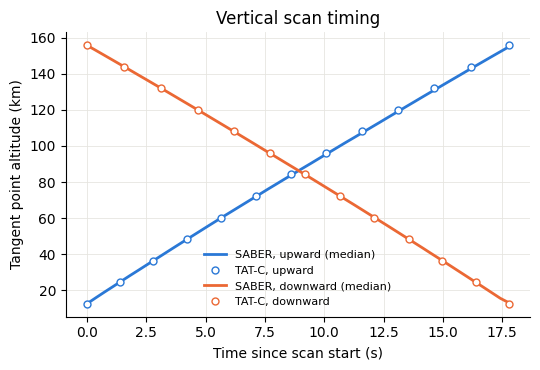

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 3.8))
grid = np.linspace(0, np.median(durations), 50)
for up, color, label in [(True, BLUE, "upward"), (False, ORANGE, "downward")]:
    measured = np.median(
        [np.interp(grid, e["elapsed"], e["tpaltitude"]) for e in events if e["upward"] == up], axis=0
    )
    ax.plot(grid, measured, color=color, lw=2, label=f"SABER, {label} (median)")
    simulated = np.median(profiles[label], axis=0)
    ax.plot(simulated[:, 0], simulated[:, 1], color=color, lw=0, marker="o", ms=5, mfc="white", label=f"TAT-C, {label}")
ax.set(xlabel="Time since scan start (s)", ylabel="Tangent point altitude (km)", title="Vertical scan timing")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## Test 4: Daily Sampling

A planning-style TAT-C run reproduces SABER's alternating scan pattern from midnight, independent of the real SABER timeline. Scans alternate upward and downward, with start spacings taken from the median values above, using two calls to `collect_limb_observations` (one per direction). The representative `position` of each TAT-C scan, at the default `sample_elevation` (the midpoint of the scan, about 84 km), is compared with SABER's tangent point at the same altitude in each SABER event. As for MLS, each SABER profile is matched to the nearest point on TAT-C's densified track.

In [11]:
gap_after_up = np.median(np.diff(starts)[upward[:-1]])
gap_after_down = np.median(np.diff(starts)[~upward[:-1]])
up_times, down_times, t = [], [], 0.0
while t < 86400:
    up_times.append(DAY0 + timedelta(seconds=t))
    t += gap_after_up
    if t < 86400:
        down_times.append(DAY0 + timedelta(seconds=t))
    t += gap_after_down
limb_obs = pd.concat(
    [
        collect_limb_observations(timed, up_times, 90.0, scan_elevations, scan_duration, ScanDirection.UPWARD),
        collect_limb_observations(timed, down_times, 90.0, scan_elevations, scan_duration, ScanDirection.DOWNWARD),
    ]
).sort_values("time", ignore_index=True)
sample_elevation = (min(scan_elevations) + max(scan_elevations)) / 2
obs_s = np.array([(t.to_pydatetime() - DAY0).total_seconds() for t in limb_obs.time])
obs_lat = np.array([p.y for p in limb_obs.position])
obs_lon = np.array([p.x for p in limb_obs.position])

# SABER tangent point at the same altitude, per event
ref_s, ref_lat4, ref_lon4 = [], [], []
for e in events:
    a = e["tpaltitude"] * 1e3
    o = np.argsort(a)
    if a.min() <= sample_elevation <= a.max():
        ref_s.append((e["datetime"][0] - DAY0).total_seconds() + np.interp(sample_elevation, a[o], e["elapsed"][o]))
        ref_lat4.append(np.interp(sample_elevation, a[o], e["tplatitude"][o]))
        ref_lon4.append(np.interp(sample_elevation, a[o], np.unwrap(e["tplongitude"], period=360)[o]))
ref_s, ref_lat4 = np.array(ref_s), np.array(ref_lat4)
ref_lon4 = (np.array(ref_lon4) + 180) % 360 - 180

dense_s = np.arange(obs_s[0], obs_s[-1], 1.0)
dense_lat = np.interp(dense_s, obs_s, obs_lat)
dense_lon = (np.interp(dense_s, obs_s, np.unwrap(obs_lon, period=360)) + 180) % 360 - 180
nearest_km = []
for s, la, lo in zip(ref_s, ref_lat4, ref_lon4):
    w = np.abs(dense_s - s) < 300
    nearest_km.append(np.min(GEOD.inv(np.full(w.sum(), lo), np.full(w.sum(), la), dense_lon[w], dense_lat[w])[2]) / 1e3)


def equator_lst(seconds, lat, lon, ascending):
    lst = (seconds / 3600 + lon / 15) % 24
    return np.median(lst[(np.abs(lat) < 3) & ascending])


test4 = pd.DataFrame(
    {
        "profiles per day": [len(ref_s), len(limb_obs)],
        "min latitude (deg)": [ref_lat4.min(), obs_lat.min()],
        "max latitude (deg)": [ref_lat4.max(), obs_lat.max()],
        "northbound equator LST (h)": [
            equator_lst(ref_s, ref_lat4, ref_lon4, np.gradient(ref_lat4) > 0),
            equator_lst(obs_s, obs_lat, obs_lon, np.gradient(obs_lat) > 0),
        ],
        "southbound equator LST (h)": [
            equator_lst(ref_s, ref_lat4, ref_lon4, np.gradient(ref_lat4) < 0),
            equator_lst(obs_s, obs_lat, obs_lon, np.gradient(obs_lat) < 0),
        ],
    },
    index=["SABER", "TAT-C"],
).T
display(test4.round(2))
summarize(nearest_km).to_frame("distance to TAT-C track (km)").T.round(3)

,SABER,TAT-C
profiles per day,1262.00,1331.00
min latitude (deg),-51.71,-51.87
max latitude (deg),83.62,83.81
northbound equator LST (h),1.17,1.18
southbound equator LST (h),16.21,16.23


,n,mean,std,median,p95 |x|,max |x|
distance to TAT-C track (km),1262.0,23.942,12.378,25.545,40.892,42.72


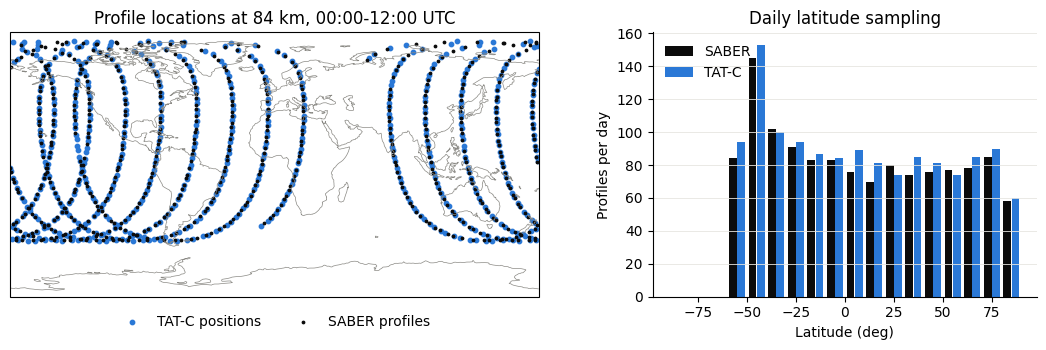

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
axes[0].remove()
ax_map = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
half = obs_s < 12 * 3600
ax_map.scatter(obs_lon[half], obs_lat[half], s=10, color=BLUE, label="TAT-C positions", transform=ccrs.PlateCarree())
ax_map.scatter(ref_lon4[ref_s < 12 * 3600], ref_lat4[ref_s < 12 * 3600], s=3, color=INK, label="SABER profiles", transform=ccrs.PlateCarree())
ax_map.coastlines(color=GRAY, linewidth=0.5)
ax_map.set_global()
ax_map.set_title(f"Profile locations at {sample_elevation / 1e3:.0f} km, 00:00-12:00 UTC")
ax_map.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2)
bins = np.arange(-90, 91, 10)
centers = (bins[1:] + bins[:-1]) / 2
axes[1].bar(centers - 2.1, np.histogram(ref_lat4, bins)[0], width=4, color=INK, label="SABER")
axes[1].bar(centers + 2.1, np.histogram(obs_lat, bins)[0], width=4, color=BLUE, label="TAT-C")
axes[1].set(xlabel="Latitude (deg)", ylabel="Profiles per day", title="Daily latitude sampling")
axes[1].grid(axis="x", visible=False)
axes[1].legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (TLE vs. SABER spacecraft position) | 5 km behind along track (TLE 10 days from epoch); 1.5 km cross-track (95th percentile) |
| 2. Tangent point at matched time and altitude | Altitude exact; 35 km horizontal (median), 50 km (95th percentile), mostly eastward; 18 km (median), 30 km (95th percentile) with SABER's precession rotation removed |
| 2. SABER's own tangency defect | 21 km (median), 40 km (95th percentile); 11 km and 28 km with precession removed |
| 3. Scan sample timing, upward and downward | Within 0.05 s (median) and 0.35 s (95th percentile) at the same altitude |
| 4. Daily sampling | Latitude range within 0.2 deg; equator local solar time within 0.02 h |

**Viewing geometry and scan timing.** A side-looking view (`scan_azimuth = 90`) places TAT-C's tangent points on the correct side of the track and at the correct distance range, and requested altitudes are reproduced exactly. SABER sweeps at a nearly constant rate in both directions, so TAT-C's constant angular-rate scan model matches its sample times to a few tenths of a second, for both `UPWARD` and `DOWNWARD` scans.

**Horizontal location.** As reported, TAT-C's tangent points differ from SABER's by a smooth, systematic offset of about 35 km, mostly eastward. SABER's own geolocation is not consistent with straight-line tangency from its reported spacecraft position by a similar amount, whereas MLS's is exactly consistent and agrees with TAT-C to 1.8 km. The main cause is a rotation of SABER's tangent points about the pole that has grown over the mission at the rate of precession since J2000 (0.34 deg in 2026), as from mixing a J2000 inertial frame with a frame of date in SABER's geolocation; it is not a time-scale error, which would give a constant rotation. With that rotation removed, the eastward offset disappears in each year checked (2002, 2008, 2014, and 2026) and TAT-C agrees with SABER to about 18 km (median), a level set mainly by the variation of SABER's viewing azimuth and by its altitude registration. The MLS validation provides the tighter bound on TAT-C's horizontal tangent point location.

**Modeling SABER with TAT-C.** Use `scan_azimuth = 90` (or 270 after a TIMED yaw maneuver), and model the alternating scans with two calls to `collect_limb_observations`, one per `ScanDirection`, with about 17.8 s scans starting alternately 81.8 s and 48.1 s apart. That cadence gives 1,331 scans per day; SABER returned 1,262 usable events on this day, about 5% fewer, because of data gaps or events without valid retrievals.

**Limitations.** This validation covers a single day, with SABER viewing to the left of the track throughout; the earlier years were checked separately and are summarized, not reproduced, here. The precession explanation is inferred from SABER's own geometry and its growth over the mission, and has not been confirmed by the SABER team. Test 4 compares against SABER's tangent points as reported, so its distances include the precession offset.